# Heart Disease Prediction by using ML
## 1. Problem Definition 
Predict whether individual has heart disease or not according given features
## 2. Data Introduction
* Data was obtained from [Kaggle](https://www.kaggle.com/datasets/sumaiyatasmeem/heart-disease-classification-dataset).

## 3. Features
We've got 13 features, and 1 target in the dataset, and it's described as below.

1. **age** - age in years

2. **sex** - gender
    * 1 : male
    * 0 : female

3. **cp** - Chest pain type
    * 0 : typical angina
    * 1 : atypical angina
    * 2 : non — anginal pain
    * 3 : asymptotic

4. **trestbps**- resting blood pressure in mmHg (unit)
    * anything above 130-140 is typically cause for concern.

5. **chol**- Serum Cholestrol in mg/dl (unit)

6. **fbs**- Fasting Blood Sugar
    * fasting blood sugar > 120mg/dl
        * 1 = true
        * 0 = false
    * '>126' mg/dL represents diabetes

7. **restecg** - resting electrocardiographic
    * 0 : normal
    * 1 : having ST-T wave abnormality
    * 2 : left ventricular hyperthrophy

8. **thalach**- maximum heart rate

9. **exang**- Exercise induced angina
    * 1 : yes
    * 0 : no

10. **oldpeak**- ST depression induced by exercise relative to rest looks at stress of heart during excercise unhealthy heart will stress more

11. **slope** - Slope of the peak exercise ST segment
    * 0 : upsloping -  better heart rate with excercise (uncommon)
    * 1 : flat -  minimal change (typical healthy heart)
    * 2 : downsloping - signs of unhealthy heart

12. **ca** - Number of major vessels (0–3) colored by flourosopy
    * colored vessel means the doctor can see the blood passing through
    * the more blood movement the better (no clots)

13. **thal** - Displays the thalassemia
    * 1,3 : normal
    * 6 : fixed defect
    * 7 : reversible defect (no proper blood movement when excercising)

14. **target** - A patient has heart diseas or not
    * 1 : yes
    * 0 : no

In [2]:
data_dict = {
'age':'age in years',
'sex': '0 = female | 1 = male',
'cp' : 'chest pain type; 0=typical angina | 1=atypical angina | 2 : non — anginal pain | 3 : asymptotic',
'trestbps' : 'resting blood pressure in mmHg (unit)',
'chol' : 'Serum Cholestrol in mg/dl (unit)',
'fbs' : 'Fasting Blood Sugar',
'restecg': 'resting electrocardiographic',
'thalach': 'maximum heart rate',
'exang': 'Exercise induced angina',
'oldpeak':'ST depression induced by exercise relative to rest looks at stress of heart during excercise unhealthy heart will stress more',
'slope' : 'Slope of the peak exercise ST segment',
'ca' : 'Number of major vessels (0–3) colored by flourosopy',
'thal' : 'Displays the thalassemia'
}

In [3]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

# Models
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score

# metrics
# from sklearn.metrics import roc_auc_score, roc_curve, ConfusionMatrixDisplay, f1_score, recall_score, precision_score, RocCurveDisplay
from sklearn.metrics import  roc_curve, ConfusionMatrixDisplay, precision_score, RocCurveDisplay, classification_report, f1_score, recall_score, precision_score

## 4. EDA

In [4]:
df = pd.read_csv('./data/heart-disease.csv')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [5]:
print(df.isna().sum())
print("===================================")
df.info()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


This is a cleaned dataset

Checking the describe Statistics

In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### 4.1 Checking if class balanced

target
1    165
0    138
Name: count, dtype: int64


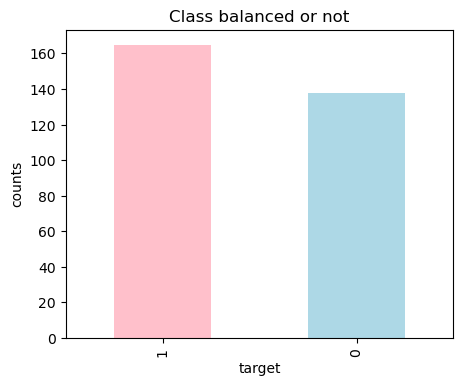

In [7]:
print(df["target"].value_counts())

df["target"].value_counts().plot(kind = "bar",
                                figsize = (5, 4),
                                color = ['pink', 'lightblue'])
plt.title("Class balanced or not")
plt.ylabel("counts");

#### Checking Heart Disease Frequency with Sex
0 = 'female'

1 = 'male'

In [8]:
pd.crosstab(df['target'],df['sex'])

sex,0,1
target,,
0,24,114
1,72,93


sex
1    207
0     96
Name: count, dtype: int64


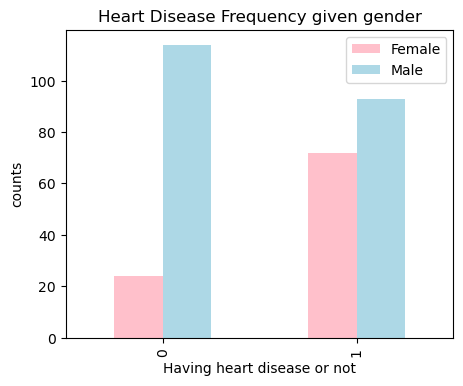

In [9]:
print(df['sex'].value_counts())
pd.crosstab(df['target'], df['sex']).plot(kind = 'bar',
                             color = ['pink', 'lightblue'],
                             figsize = (5,4))
plt.title("Heart Disease Frequency given gender")
plt.legend(["Female", "Male"])
plt.xlabel("Having heart disease or not")
plt.ylabel("counts");

We have more males than females in the dataset. Among males, the difference between those with and without heart disease is relatively small. In contrast, heart disease frequency among females is quite imbalanced. The number of females with heart disease is more than three times that of those without. This imbalance may introduce bias when training models. we can keep this in mind.

What about age? How does age affects the heart disease development?

Let's check on the distribution of age in the dataset firstly.

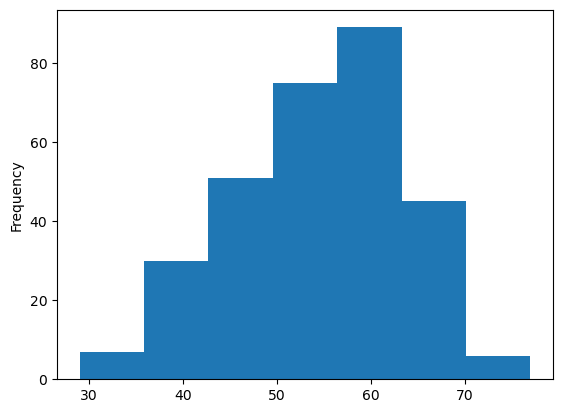

In [10]:
df['age'].plot.hist(bins = 7);

The majority of individuals in the dataset fall between the age of 55 and 65.

Let's check the relationship among age, maximum heart rate, and heart disease with a plot.

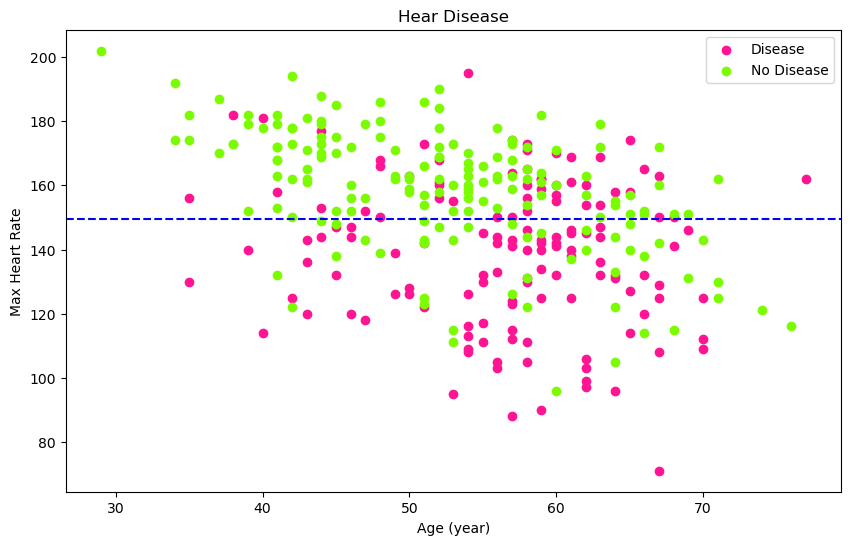

In [11]:
fig, ax = plt.subplots(figsize = (10, 6))

ax.scatter(df.age[df.target == 0], df.thalach[df.target == 0], c = "deeppink")
ax.scatter(df.age[df.target == 1], df.thalach[df.target == 1], c = "lawngreen")

ax.set(title = "Hear Disease",
       xlabel = "Age (year)",
       ylabel = "Max Heart Rate")
ax.axhline(np.mean(df["thalach"]), c = 'blue', linestyle = "--")
ax.legend(["Disease", "No Disease"]);

The plot suggests that as age increases, the maximum heart rate tends to decrease. Furthermore, the likelihood of developing heart disease increases when the maximum heart rate is below average(There are more pink dots under the blue line).

Let's make correlation matrix to check which features have stronger relationsip with the target

In [12]:
# correlation

df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


NameError: name 'sns' is not defined

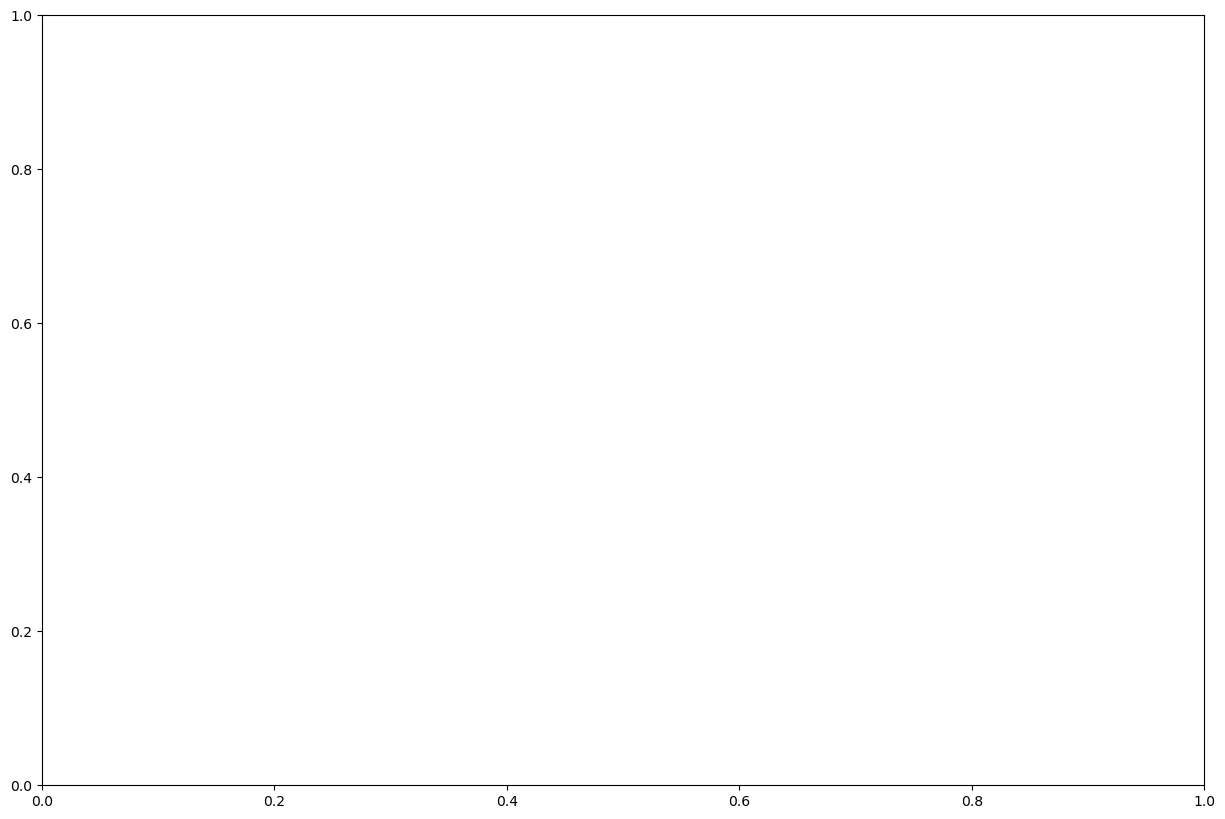

In [13]:
corr_matrix = df.corr()

fig, ax = plt.subplots(figsize = (15, 10))
ax = sns.heatmap(corr_matrix,
                annot = True,
                linewidth = 0.5,
                fmt = ".2f",
                cmap = "YlGnBu")

From the correlation matrix, several important relationshiops can be observed

The correlation matrix shows that **cp** and **thalach** have relatively strong positive correlations with the target, while **exang** and **oldpeak** exhibit relatively strong negative correlations.

### 5. Modelling

#### 5.1 Split the data into training and test set

In [14]:
from sklearn.model_selection import train_test_split

X = df.drop(['target'], axis = 1)
y = df['target'].to_numpy()

np.random.seed(42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [15]:
# Checking the dataset

X_train.shape, X_test.shape, y_train.shape, y_test.shape
X_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
132,42,1,1,120,295,0,1,162,0,0.0,2,0,2
202,58,1,0,150,270,0,0,111,1,0.8,2,0,3
196,46,1,2,150,231,0,1,147,0,3.6,1,0,2
75,55,0,1,135,250,0,0,161,0,1.4,1,0,2
176,60,1,0,117,230,1,1,160,1,1.4,2,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,50,1,2,140,233,0,1,163,0,0.6,1,1,3
71,51,1,2,94,227,0,1,154,1,0.0,2,1,3
106,69,1,3,160,234,1,0,131,0,0.1,1,1,2
270,46,1,0,120,249,0,0,144,0,0.8,2,0,3


In [16]:
y_train

array([1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1])

#### 5.2 Model Selection

**I am trying the following ML models:**

Models are selected by referring to the [map](https://scikit-learn.org/stable/machine_learning_map.html). Additionally, since this is a binary classification problem, `Logistic Regression` and `Random Forest` are also considered.

1. LinearSVC
3. K-Nearest Neighbors Classifier
4. Logistic Regression
5. Random Forest Classifier

#### Evaluation Function
Before training models, creating an reusable evaluation function is easier to go.

In [17]:
def model_eval(model, X_train, y_train, X_test, y_test):
    
    fig = plt.figure(figsize = (25, 8))   

    # Confusion Matrix - training dataset
    ax0 = fig.add_subplot(1, 3, 1)
    ConfusionMatrixDisplay.from_estimator(model, X_train, y_train, ax = ax0)
    ax0.set(title = f"Training set accuracy: {model.score(X_train, y_train) * 100:.2f}%")

    # Confusion Matrix - Test dataset
    ax1 = fig.add_subplot(1, 3, 2)
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, ax = ax1)
    ax1.set(title = f"Test set accuracy: {model.score(X_test, y_test)*100:.2f}%")

    # roc curve
    ax2 = fig.add_subplot(1,3,3)
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax = ax2)   

    # classification report
    print(classification_report(y_test, model.predict(X_test)))    

#### 5.3 Fit models

##### Linear SVC

              precision    recall  f1-score   support

           0       0.86      0.86      0.86        29
           1       0.88      0.88      0.88        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



{'C': 1.0,
 'class_weight': None,
 'dual': 'auto',
 'fit_intercept': True,
 'intercept_scaling': 1,
 'loss': 'squared_hinge',
 'max_iter': 1000,
 'multi_class': 'ovr',
 'penalty': 'l2',
 'random_state': None,
 'tol': 0.0001,
 'verbose': 0}

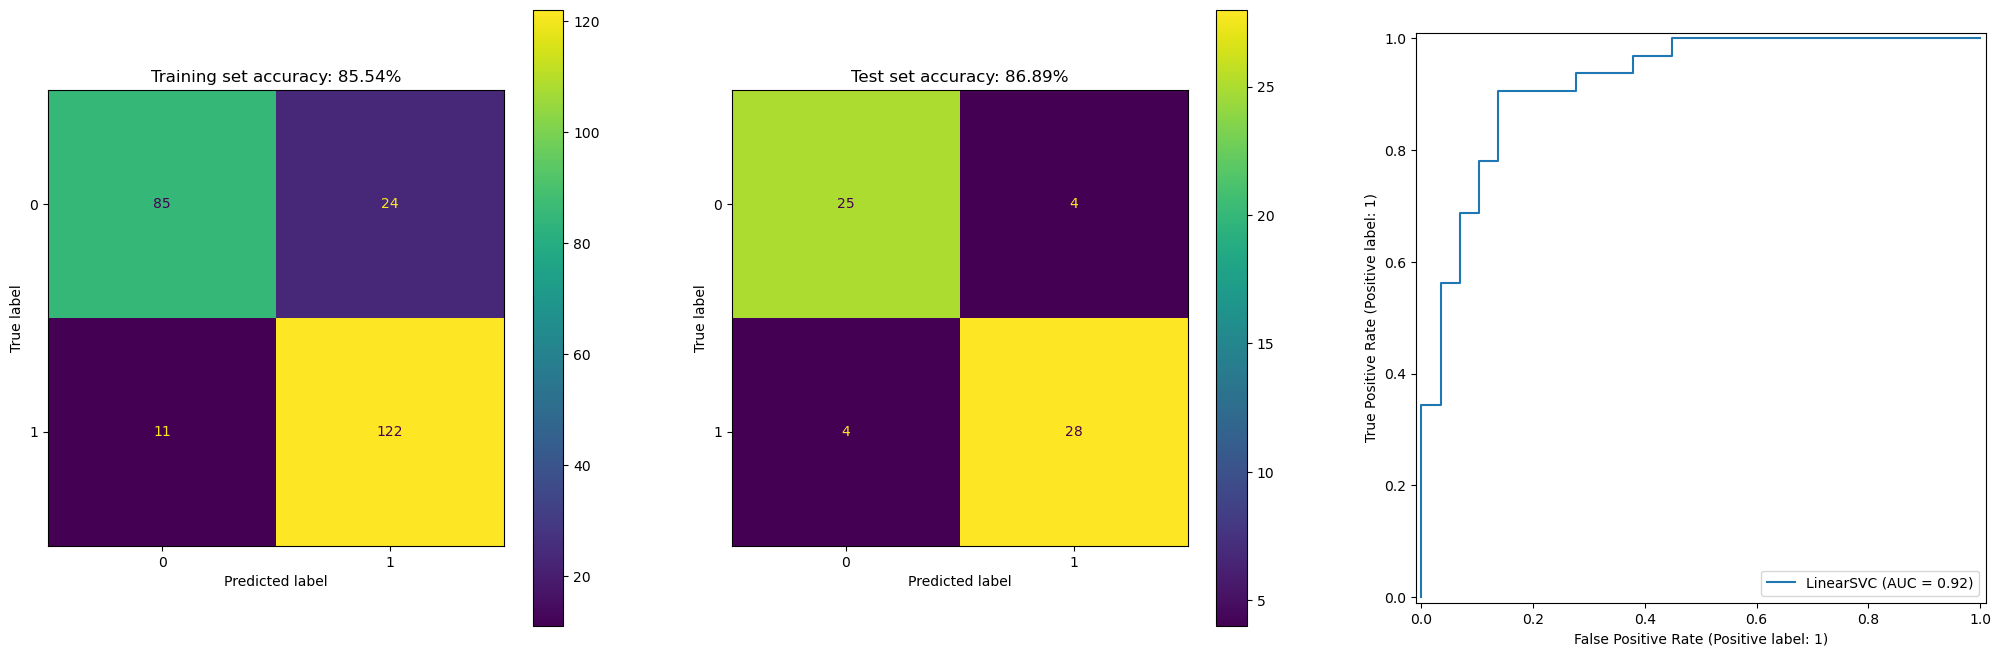

In [18]:
lsvc_clf = LinearSVC()
lsvc_clf.fit(X_train, y_train)
model_eval(lsvc_clf, X_train, y_train, X_test, y_test)

lsvc_clf.get_params()

Tuning Linear SVC by GridSearchCV

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



{'C': 0.01}

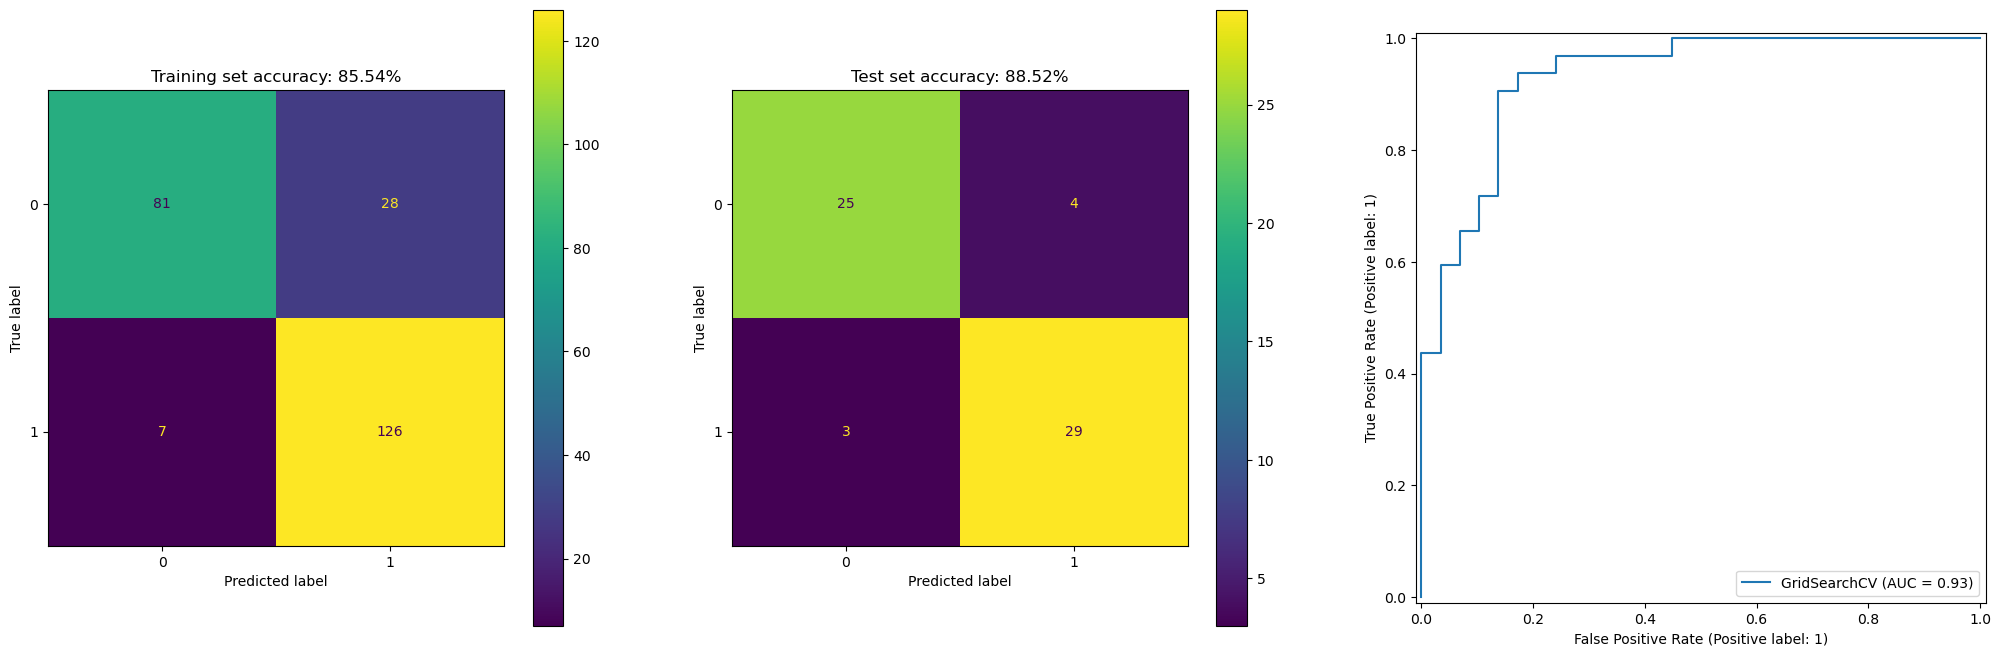

In [19]:
param_grid = {"C": [0.01, 0.1, 1, 10, 100]}

lsvm_grid_cv = GridSearchCV(LinearSVC(max_iter = 5000),
                            param_grid,
                            cv =5)
lsvm_grid_cv.fit(X_train, y_train)  

model_eval(lsvm_grid_cv, X_train, y_train, X_test, y_test)
lsvm_grid_cv.best_params_

In our case, the main concern is failing to diagnose a patient who actually has heart disease. Therefore, we first focus on recall, which is 0.91, indicating strong performance. This is also reflected in the confusion matrix of the test set, where only one sample was misclassified as negative despite the individual having heart disease. In addition, the overall accuracy is slightly improved from approximately 86% to 88%.

However, since our data is slightly imbalanced, F1-score should also be taken into account.
The f1-score is slightly increased from 0.88 to 0.89 after applying the optimal parameter through grid search.

##### Further experiments will be conducted to assess the performance of other models:
* K-Nearest Neighbors Classifier
* Logistic Regression
* Random Forest Classifier

It will be performed in one go by applying `for loop`

In [20]:
# from sklearn.svm import LinearSVC, SVC
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import GridSearchCV

trained_models = {}

models = {'KNN' : KNeighborsClassifier(),
         'LogisticRegression' : LogisticRegression(),
         'RandomForest' : RandomForestClassifier()}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[model_name] = model

/Users/eleanor/git_local_repository/conda_env/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### 6. Model Evaluation

              precision    recall  f1-score   support

           0       0.69      0.62      0.65        29
           1       0.69      0.75      0.72        32

    accuracy                           0.69        61
   macro avg       0.69      0.69      0.69        61
weighted avg       0.69      0.69      0.69        61



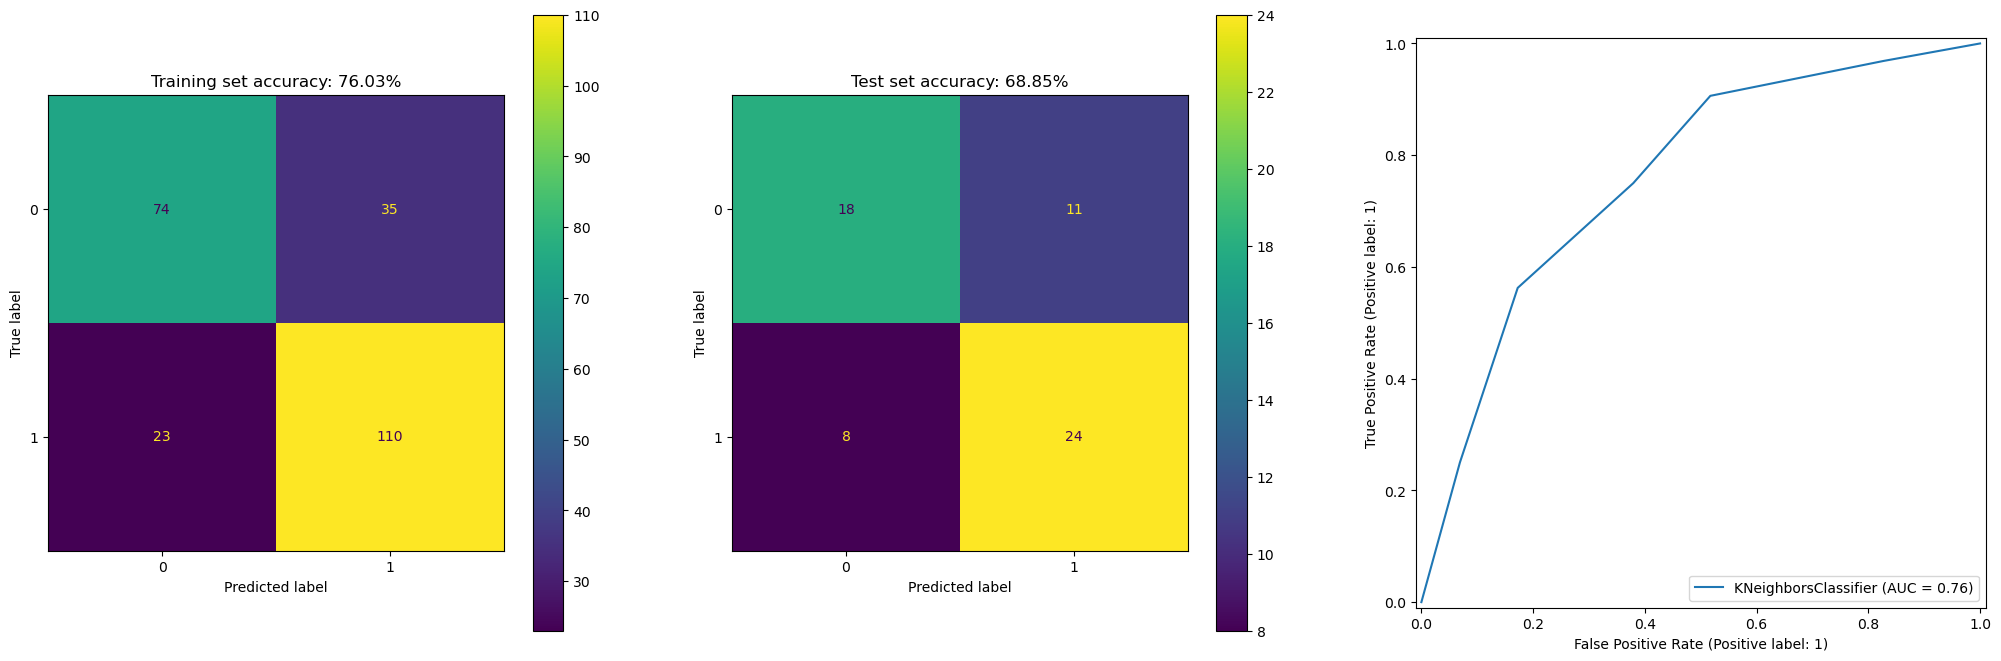

In [21]:
model_eval(trained_models['KNN'], X_train, y_train, X_test, y_test)

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



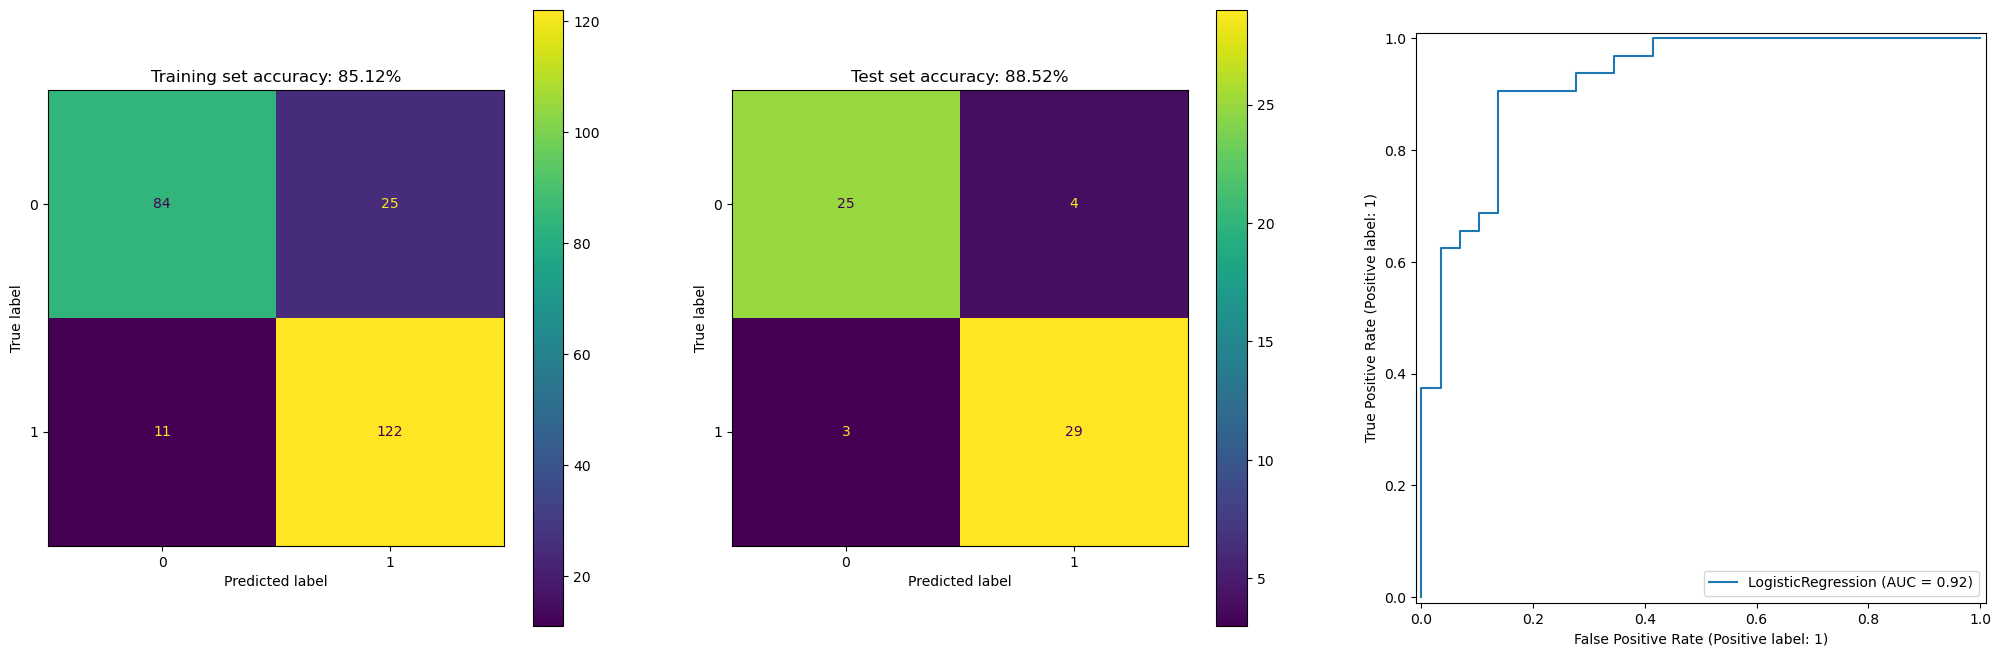

In [22]:
model_eval(trained_models['LogisticRegression'], X_train, y_train, X_test, y_test)

              precision    recall  f1-score   support

           0       0.89      0.83      0.86        29
           1       0.85      0.91      0.88        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



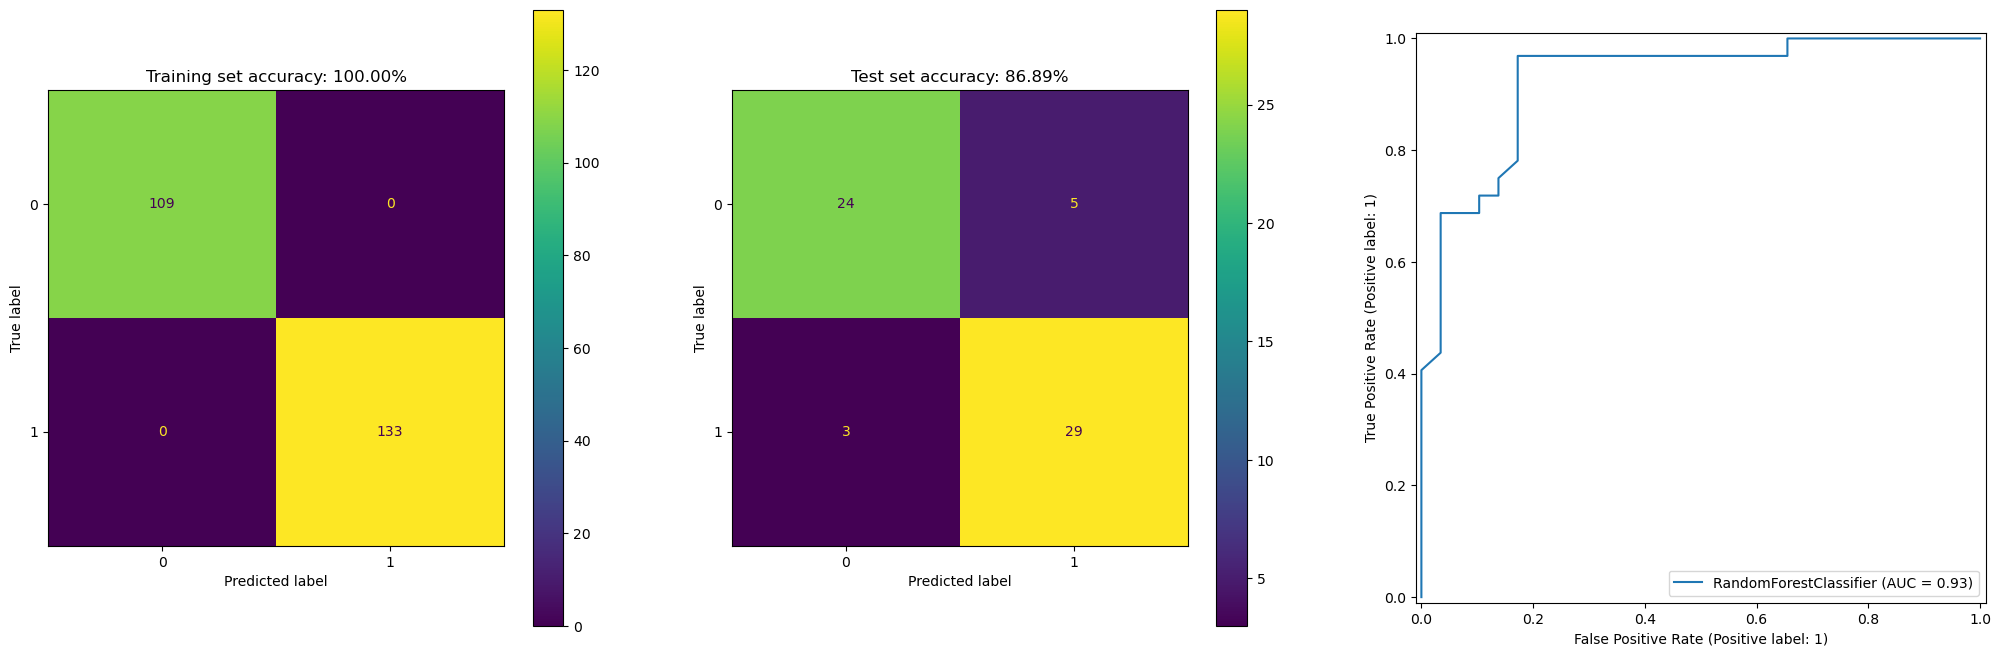

In [23]:
model_eval(trained_models['RandomForest'], X_train, y_train, X_test, y_test)

### Model comparison

In [24]:
# acc_dict = {trained_models['KNN'].score(X_test, y_test), trained_models['LogisticRegression'].score(X_test, y_test), trained_models['RandomFroest'].score(X_test, y_test)

            
# model_comparison

accuracy_dict = {}
f1_score_dict = {}
recall_dict = {}
precision_dict = {}

for model in 'KNN', 'LogisticRegression', 'RandomForest':
    accuracy_dict[model] = trained_models[model].score(X_test, y_test)

    y_pred = trained_models[model].predict(X_test)
    f1_score_dict[model] = f1_score(y_pred, y_test)
    recall_dict[model] = recall_score(y_pred, y_test)
    precision_dict[model] = precision_score(y_pred, y_test)
    

# LinearSVC metrics
accuracy_dict['LinearSVC'] = lsvc_clf.score(X_test, y_test)
y_pred = lsvc_clf.predict(X_test)
f1_score_dict['LinearSVC'] = f1_score(y_pred, y_test)
recall_dict['LinearSVC'] = recall_score(y_pred, y_test)
precision_dict['LinearSVC'] = precision_score(y_pred, y_test)

model_comparison = accr_compare.T
model_comparison['f1'] = f1_score_dict.values()
model_comparison['recall'] = recall_dict.values()
model_comparison['precision'] = precision_dict.values()
model_comparison

NameError: name 'accr_compare' is not defined

In [25]:
model_comparison.plot(kind = 'bar',
                     figsize = (8, 6),
                     cmap = "plasma");

plt.title("Model metrics comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

NameError: name 'model_comparison' is not defined

The plot indicates that LogisticRegression model performs the best whereas model K- Nearest Neighbors Classifier performs the worst, with an accuracy of around 68% only.


Several intereting observations can be made. The recall scores of Linear SVC and Logistic Regression are nearly identical. Additionally, the Random Forest model achieves 100% accuracy on the training set, which may suggests that the model may be overfitting.

#### Applying `Cross validation`
Cross-validation is applying in order to mitigate the risk of obtaining biased results from a single data split

In [26]:
np.random.seed(45)

models = { 'Linear SVC' : LinearSVC(),
        'KNN' : KNeighborsClassifier(),
         'LogisticRegression' : LogisticRegression(),
         'RandomForest' : RandomForestClassifier()}

models_acc = {}
for model_name, model in models.items():
    cv_acc = {}
    for score in "accuracy", "precision", "f1", "recall":
        cv_acc[score] = cross_val_score(model, X, y, cv = 50, scoring = score)
    models_acc[model_name] = cv_acc
models_acc

/Users/eleanor/git_local_repository/conda_env/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/eleanor/git_local_repository/conda_env/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://s

{'Linear SVC': {'accuracy': array([1.        , 0.85714286, 0.71428571, 1.        , 0.83333333,
         0.83333333, 1.        , 0.83333333, 0.83333333, 1.        ,
         0.5       , 1.        , 0.83333333, 0.66666667, 0.83333333,
         0.66666667, 1.        , 1.        , 1.        , 0.83333333,
         1.        , 0.83333333, 1.        , 0.83333333, 1.        ,
         0.33333333, 0.83333333, 0.83333333, 0.83333333, 0.83333333,
         1.        , 0.83333333, 1.        , 0.83333333, 1.        ,
         0.5       , 0.83333333, 1.        , 1.        , 0.83333333,
         0.83333333, 0.33333333, 0.83333333, 0.66666667, 0.66666667,
         0.83333333, 0.83333333, 0.66666667, 0.83333333, 0.5       ]),
  'precision': array([1.        , 0.8       , 0.66666667, 1.        , 0.8       ,
         1.        , 1.        , 0.8       , 0.8       , 1.        ,
         0.6       , 1.        , 1.        , 0.75      , 0.8       ,
         0.6       , 1.        , 1.        , 1.        , 0.75 

Average cross-validation metrics.

In [27]:
for model, metrics in models_acc.items():
    print(model)
    for metric, accuracy_lst in metrics.items():
        print(f"{metric} avg: {np.mean(accuracy_lst)}")
    print()

Linear SVC
accuracy avg: 0.8280952380952382
precision avg: 0.823
f1 avg: 0.84831746031746
recall avg: 0.9000000000000001

KNN
accuracy avg: 0.6528571428571428
precision avg: 0.6826666666666665
f1 avg: 0.6856031746031745
recall avg: 0.735

LogisticRegression
accuracy avg: 0.8347619047619048
precision avg: 0.8323333333333334
f1 avg: 0.8567301587301586
recall avg: 0.9083333333333333

RandomForest
accuracy avg: 0.8242857142857144
precision avg: 0.861
f1 avg: 0.8458730158730157
recall avg: 0.85



In [28]:
models_acc_avg = models_acc
for model, metrics in models_acc.items(): 
    for metric, accuracy_lst in metrics.items():        
        models_acc_avg[model][metric] = round(np.mean(accuracy_lst), 3)

pd.DataFrame(models_acc_avg).T

,accuracy,precision,f1,recall
Linear SVC,0.828,0.823,0.848,0.900
KNN,0.653,0.683,0.686,0.735
LogisticRegression,0.835,0.832,0.857,0.908
RandomForest,0.824,0.861,0.846,0.850


Visualisation

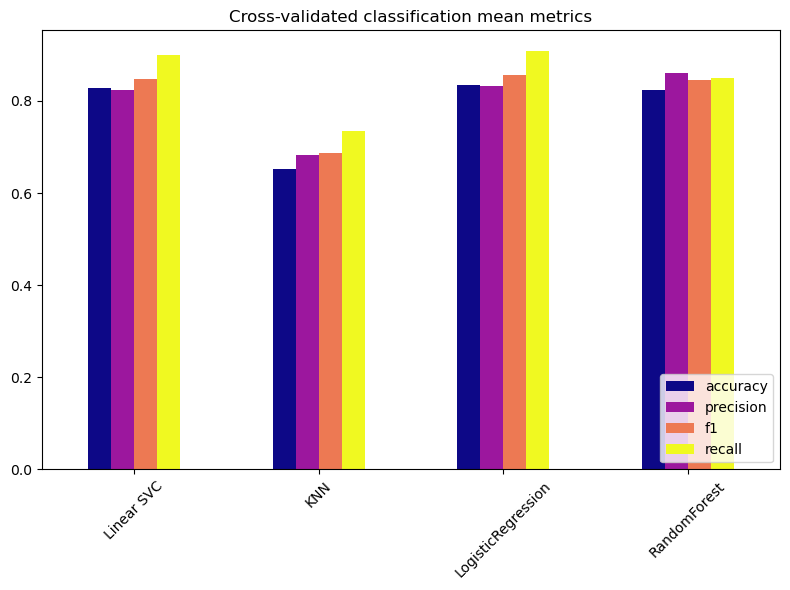

In [29]:
pd.DataFrame(models_acc_avg).T.plot(kind = 'bar',
                                    figsize = (8,6),
                                    cmap = 'plasma',
                                   title = "Cross-validated classification mean metrics")
plt.legend(loc = 'lower right')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show();

The average recall scores among LinearSVC, LogisticRegression, and RandomForest models are slightly increase. However, the precision scores are slightly decrease. Having said that, in this case, recall is much important than precision.

After applying Cross validation, LogisticRegression model still performs the best. Thus, we will then apply hyper parameter tunning on Logistic model to see if the model can be improved.

### Hyper parameter tuning


In [30]:
log_reg_grid = {"C": np.logspace(-4, 4, 30),
                "solver": ["liblinear"]}

gs_log_reg = GridSearchCV(LogisticRegression(),
                          param_grid=log_reg_grid,
                          cv=5,
                          verbose=True)

gs_log_reg.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': array([1.0000...00000000e+04]), 'solver': ['liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the

Check the best hyperparameters

In [31]:
gs_log_reg.best_params_

{'C': np.float64(0.20433597178569418), 'solver': 'liblinear'}

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



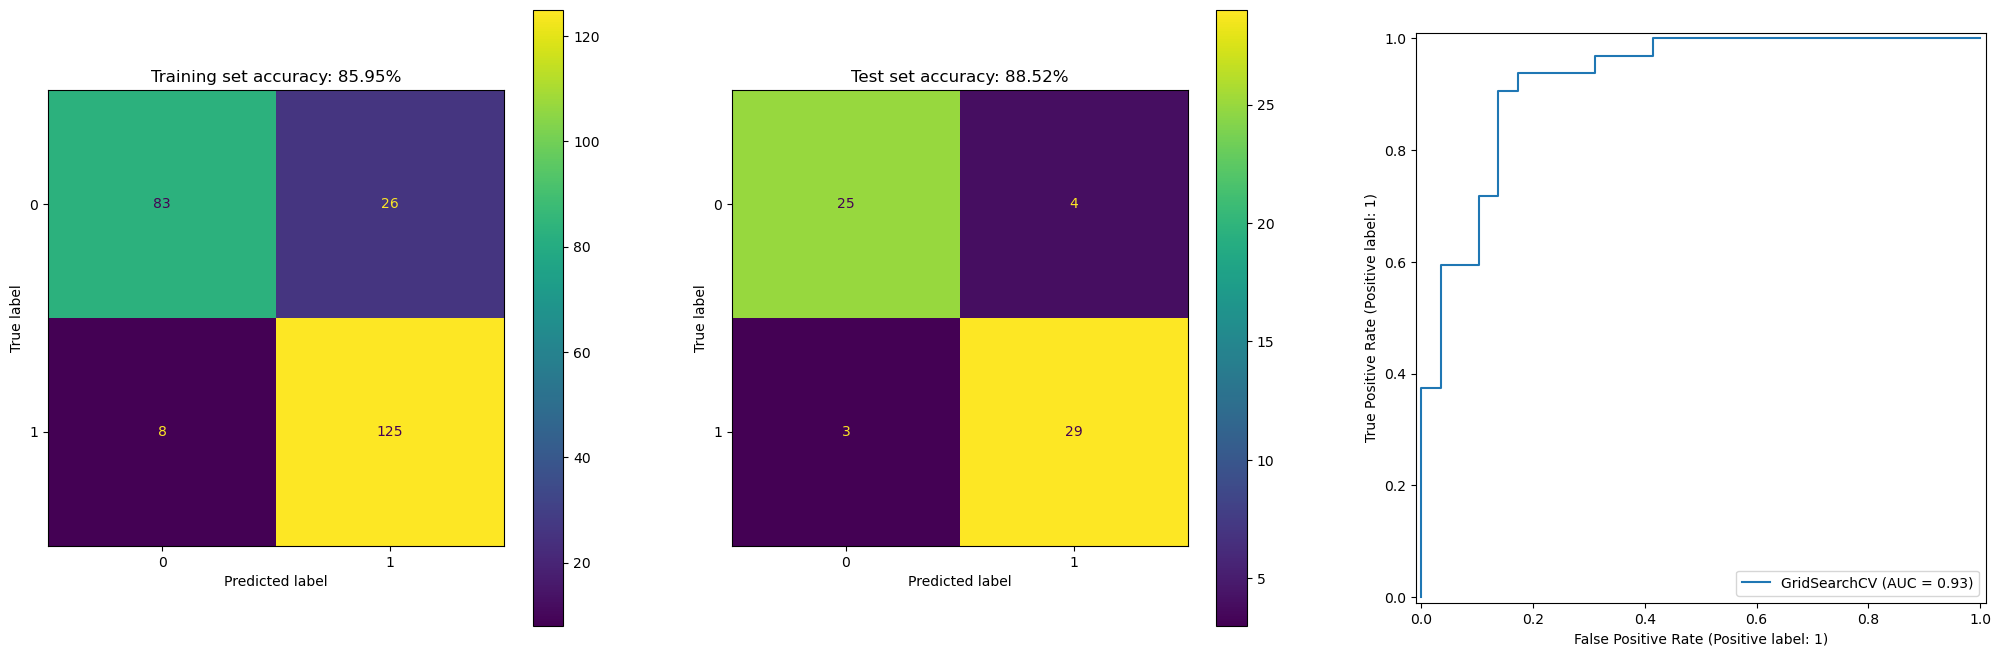

In [32]:
model_eval(gs_log_reg, X_train, y_train, X_test, y_test)

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



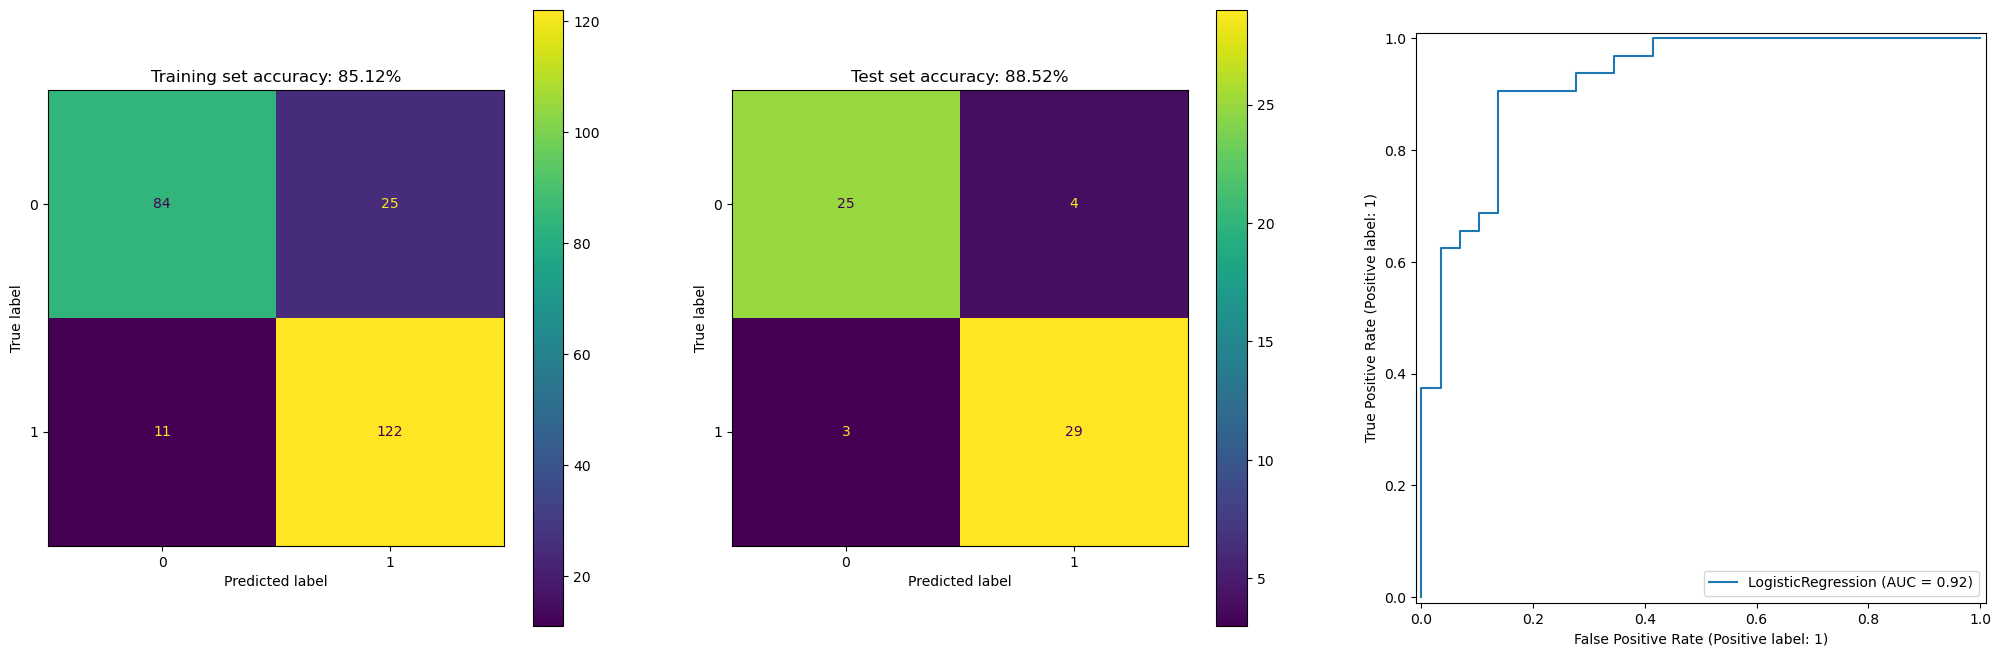

In [33]:
# compare the metrics to our baseline Logistic Regression model
model_eval(trained_models['LogisticRegression'], X_train, y_train, X_test, y_test) # Our firest logisticregression model

Hypterparameter tuning with GridSearchCV did not lead to significant performance improvement for the Logistic Regression model.

### 7. Feature Importance

In [34]:
logistic_clf = LogisticRegression(C = 0.20433597178569418, # applying the optimistic parameters by GridSearchCV
                                  solver = 'liblinear') 
logistic_clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.20433597178569418
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.

In [35]:
logistic_clf.coef_

array([[ 0.00316728, -0.86044654,  0.66067039, -0.01156993, -0.00166374,
         0.04386106,  0.3127585 ,  0.02459361, -0.60413082, -0.56862801,
         0.45051629, -0.63609898, -0.67663371]])

In [36]:
# Match coef's of features to columns
feature_dict = dict(zip(df.columns, list(logistic_clf.coef_[0])))

feature_df = pd.DataFrame(feature_dict, columns = feature_dict.keys(),
            index = [0])
feature_df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,0.003167,-0.860447,0.66067,-0.01157,-0.001664,0.043861,0.312758,0.024594,-0.604131,-0.568628,0.450516,-0.636099,-0.676634


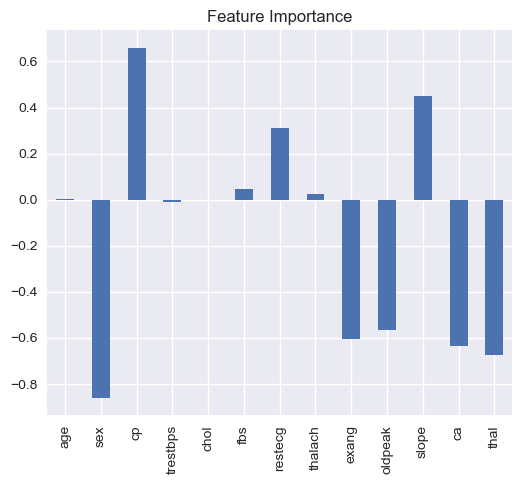

In [37]:
# plt.style.available
plt.style.use('seaborn-v0_8')

feature_df.T.plot.bar(title="Feature Importance",
                      figsize = (6, 5),
                      legend = False);

# Reference
* [sklearn Docs](https://scikit-learn.org/stable/index.html)
* [ZTM Bootcamp by Daniel Bourke](https://github.com/mrdbourke/zero-to-mastery-ml/blob/master/section-3-structured-data-projects/end-to-end-heart-disease-classification.ipynb)